<a href="https://colab.research.google.com/github/NIKUNJ-PROGRAMMER/PRE-PLACEMENT/blob/main/Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [28]:
# Data manipulation and datetime handling
import pandas as pd
import numpy as np
import datetime as dt

# Visualization for the Elbow Method
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning, Scaling, and Evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Tool for saving the model
import joblib

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


Loading and Inspecting Dataset

In [29]:
# Load the dataset (ensure 'OnlineRetail (3).csv' is uploaded)
retail_df = pd.read_csv('OnlineRetail (3).csv', encoding='unicode_escape')

print("First 5 rows of the dataset:")
display(retail_df.head())

print("\nMissing Values Count:")
display(retail_df.isnull().sum())

First 5 rows of the dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Missing Values Count:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Data Cleaning

In [30]:
# Drop rows where CustomerID is missing
retail_df.dropna(subset=['CustomerID'], inplace=True)

# Remove returns and cancelled orders (negative quantity or price)
retail_df = retail_df[(retail_df['Quantity'] > 0) & (retail_df['UnitPrice'] > 0)]

# Calculate the Total Amount for each line item
retail_df['TotalAmount'] = retail_df['Quantity'] * retail_df['UnitPrice']

# Convert InvoiceDate to datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

print(f"Data cleaned! Remaining rows: {retail_df.shape[0]}")

Data cleaned! Remaining rows: 397884


RFM Feature Engineering

In [31]:
# Create a snapshot date (1 day after the last transaction in the dataset)
snapshot_date = retail_df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID and calculate Recency, Frequency, and Monetary values
rfm = retail_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalAmount': 'sum'                                      # Monetary
})

# Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print("RFM Table generated!")
display(rfm.head())

RFM Table generated!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


Scaling the Data

In [32]:
# Initialize the standard scaler
scaler = StandardScaler()

# Fit and transform the RFM data so all features have equal weight
rfm_scaled = scaler.fit_transform(rfm)

# Convert back to a DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

print("Data successfully scaled!")
display(rfm_scaled_df.head())

Data successfully scaled!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


The Elbow Method

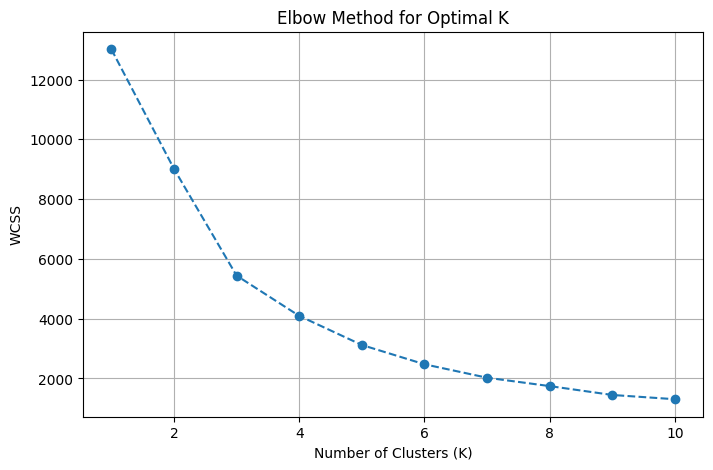

In [33]:
# Calculate WCSS for different numbers of clusters
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Visually, the "elbow" typically bends heavily around K=3

Training the K-Means Model & Evaluation

In [34]:
# We will proceed with K=3 clusters based on standard RFM analysis
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_model.fit(rfm_scaled_df)

# Assign the generated cluster labels back to our original RFM dataframe
rfm['Cluster'] = kmeans_model.labels_

# Evaluate using the Silhouette Score
sil_score = silhouette_score(rfm_scaled_df, kmeans_model.labels_)
print("--- MODEL EVALUATION ---")
print(f"Silhouette Score: {sil_score:.4f}")

--- MODEL EVALUATION ---
Silhouette Score: 0.5942


Business Insights(Cluster Profiles)

In [35]:
# Calculate the average Recency, Frequency, and Monetary value for each cluster
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("--- CUSTOMER SEGMENTATION PROFILES ---")
display(cluster_analysis)

# You can use these averages to define who is in Cluster 0, 1, and 2.

--- CUSTOMER SEGMENTATION PROFILES ---


Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0        247.11      1.58    631.42  1082
1         41.45      4.67   1855.94  3230
2          6.04     66.42  85904.35    26

Saving Final Model

In [36]:
# Save the trained K-Means model to a file
joblib.dump(kmeans_model, 'online_retail_segmentation_model.pkl')
print("Model saved successfully as 'online_retail_segmentation_model.pkl'. Please download it for submission.")

Model saved successfully as 'online_retail_segmentation_model.pkl'. Please download it for submission.
